SFT PAPER I — STANDARD-SIREN DISTANCE RESIDUAL

alpha = 0.99
z = 0.5 : Delta_siren = +0.151794%
z = 1.0 : Delta_siren = +0.188388%
z = 1.5 : Delta_siren = +0.189846%
z = 2.0 : Delta_siren = +0.182558%
z = 3.0 : Delta_siren = +0.166036%
z = 4.0 : Delta_siren = +0.153282%

alpha = 1.00
z = 0.5 : Delta_siren = +0.000000%
z = 1.0 : Delta_siren = +0.000000%
z = 1.5 : Delta_siren = +0.000000%
z = 2.0 : Delta_siren = +0.000000%
z = 3.0 : Delta_siren = +0.000000%
z = 4.0 : Delta_siren = +0.000000%

alpha = 1.01
z = 0.5 : Delta_siren = -0.152139%
z = 1.0 : Delta_siren = -0.189526%
z = 1.5 : Delta_siren = -0.191563%
z = 2.0 : Delta_siren = -0.184588%
z = 3.0 : Delta_siren = -0.168279%
z = 4.0 : Delta_siren = -0.155533%


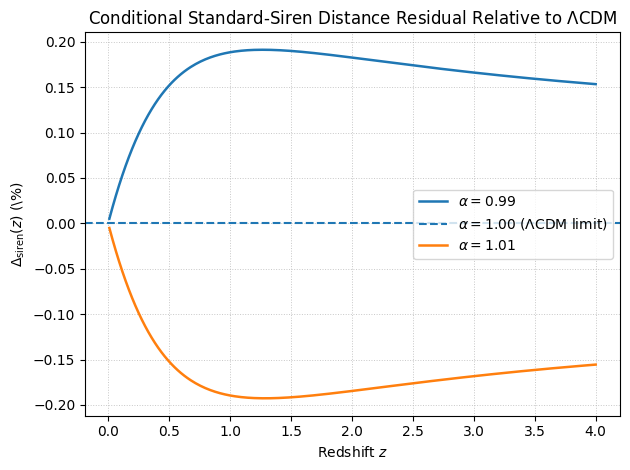

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# ============================================================
# SFT PAPER I
# Conditional Standard-Siren Distance Residual
# ============================================================

# ------------------------------------------------------------
# Paper I baseline cosmological parameters
# ------------------------------------------------------------

Omega_m0 = 0.31500
Omega_r0 = 9.034e-5
Omega_DE0 = 0.68491


# ------------------------------------------------------------
# Dimensionless expansion histories
# ------------------------------------------------------------

def E_LCDM(z):
    """
    Dimensionless LambdaCDM expansion rate E(z) = H(z)/H0.
    """
    return np.sqrt(
        Omega_m0 * (1.0 + z)**3
        + Omega_r0 * (1.0 + z)**4
        + Omega_DE0
    )


def E_SFT(z, alpha):
    """
    Dimensionless SFT expansion rate E(z) = H(z)/H0
    for the Paper I dark-energy scaling law.
    """
    return np.sqrt(
        Omega_m0 * (1.0 + z)**3
        + Omega_r0 * (1.0 + z)**4
        + Omega_DE0 * (1.0 + z)**(-3.0 * (1.0 - alpha))
    )


# ------------------------------------------------------------
# Dimensionless luminosity-distance integral
# ------------------------------------------------------------

def distance_integral(z, E_function):
    return quad(
        lambda zp: 1.0 / E_function(zp),
        0.0,
        z,
        epsabs=1e-11,
        epsrel=1e-11
    )[0]


# ------------------------------------------------------------
# Conditional standard-siren residual
#
# Delta_siren =
# d_L^SFT / d_L^LCDM - 1
#
# The common factors (1+z)c/H0 cancel in the ratio.
# ------------------------------------------------------------

def delta_siren(z, alpha):

    d_sft = distance_integral(
        z,
        lambda zp: E_SFT(zp, alpha)
    )

    d_lcdm = distance_integral(
        z,
        E_LCDM
    )

    return d_sft / d_lcdm - 1.0


# ------------------------------------------------------------
# Check benchmark numerical values
# ------------------------------------------------------------

print("=" * 72)
print("SFT PAPER I — STANDARD-SIREN DISTANCE RESIDUAL")
print("=" * 72)

for alpha in [0.99, 1.00, 1.01]:
    print(f"\nalpha = {alpha:.2f}")

    for z in [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]:

        if alpha == 1.00:
            residual_percent = 0.0
        else:
            residual_percent = 100.0 * delta_siren(z, alpha)

        print(
            f"z = {z:3.1f} : "
            f"Delta_siren = {residual_percent:+.6f}%"
        )


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

z_values = np.linspace(0.01, 4.0, 300)

# alpha = 0.99
residual_099 = np.array([
    100.0 * delta_siren(z, 0.99)
    for z in z_values
])

plt.plot(
    z_values,
    residual_099,
    linewidth=1.8,
    label=r'$\alpha=0.99$'
)

# alpha = 1.00 is exactly the LambdaCDM limit.
# Plot this as the zero-reference line.
plt.axhline(
    0.0,
    linestyle='--',
    linewidth=1.5,
    label=r'$\alpha=1.00$ ($\Lambda$CDM limit)'
)

# alpha = 1.01
residual_101 = np.array([
    100.0 * delta_siren(z, 1.01)
    for z in z_values
])

plt.plot(
    z_values,
    residual_101,
    linewidth=1.8,
    label=r'$\alpha=1.01$'
)

# Horizontal and vertical grid lines
plt.grid(
    True,
    which='major',
    linestyle=':',
    linewidth=0.7,
    alpha=0.7
)

plt.xlabel(r'Redshift $z$')
plt.ylabel(r'$\Delta_{\rm siren}(z)$ (\%)')

plt.title(
    r'Conditional Standard-Siren Distance Residual Relative to $\Lambda$CDM'
)

plt.legend()

plt.tight_layout()

plt.savefig(
    'standard_siren_SFT_LCDM_residual.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()